# Time Series Forecasting
A time-series model learns from observations arranged in chronological order and uses past values to predict later values.

In our dataset, each row is not one consecutive day globally. It is a weather observation for a particular location at a particular time. Therefore, before forecasting , the dataset is turned into single ordered series.

## Daily Country-balanced Global Average Temperature


- Calculate the average temperature for each country on each date.
- Average those country values to produce one global value per day.
- Use the past daily values to predict future daily values.

The country-balanced approach prevents countries with many sampled cities from having much more influence than countries with only one or two sampled cities.

In [198]:
import pandas as pd
import matplotlib.pyplot as plt


In [199]:
df = pd.read_csv(
    "weather_cleaned.csv",
    parse_dates=["last_updated"]
)

In [200]:
print("Dataset shape:", df.shape)
print("\nDate column type:")
print(df["last_updated"].dtype)

print("\nDate range:")
print("Start:", df["last_updated"].min())
print("End:", df["last_updated"].max())

print("\nUnique timestamps:", df["last_updated"].nunique())
print("Unique calendar dates:", df["last_updated"].dt.date.nunique())

print("\nUnique countries:", df["country"].nunique())
print("Unique locations:", df["location_name"].nunique())

Dataset shape: (153586, 38)

Date column type:
datetime64[us]

Date range:
Start: 2024-05-16 02:45:00
End: 2026-07-18 19:00:00

Unique timestamps: 25544
Unique calendar dates: 793

Unique countries: 186
Unique locations: 217


In [201]:
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338.0,...,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,13
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320.0,...,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280.0,...,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215.0,...,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150.0,...,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153581,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,2026-07-18 01:45:00,17.9,Mist,6.1,155.0,...,06:53 PM,10:03 AM,10:26 PM,Waxing Crescent,18.0,2026,7,July,Saturday,1
153582,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,2026-07-18 12:45:00,35.1,Cloudy,9.0,251.0,...,06:40 PM,09:01 AM,09:36 PM,Waxing Crescent,14.0,2026,7,July,Saturday,12
153583,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,2026-07-18 08:45:00,22.8,Sunny,6.1,352.0,...,06:37 PM,09:20 AM,09:49 PM,Waxing Crescent,16.0,2026,7,July,Saturday,8
153584,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,2026-07-18 07:45:00,12.7,Cloudy,7.9,86.0,...,05:52 PM,09:35 AM,09:53 PM,Waxing Crescent,16.0,2026,7,July,Saturday,7


All observations from the same calendar date should have the same daily timestamp.

In [202]:
forecast_df = df[
    [
        "last_updated",
        "country",
        "location_name",
        "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "uv_index"
    ]
].copy()

forecast_df["date"] = (
    forecast_df["last_updated"]
    .dt.floor("D")
)

display(forecast_df.head())

,last_updated,country,location_name,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,uv_index,date
0,2024-05-16 13:15:00,Afghanistan,Kabul,26.6,24.0,1012.0,13.3,0.0,30.0,7.0,2024-05-16
1,2024-05-16 10:45:00,Albania,Tirana,19.0,94.0,1012.0,11.2,0.1,75.0,5.0,2024-05-16
2,2024-05-16 09:45:00,Algeria,Algiers,23.0,29.0,1011.0,15.1,0.0,0.0,5.0,2024-05-16
3,2024-05-16 10:45:00,Andorra,Andorra La Vella,6.3,61.0,1007.0,11.9,0.3,100.0,2.0,2024-05-16
4,2024-05-16 09:45:00,Angola,Luanda,26.0,89.0,1011.0,13.0,0.0,50.0,8.0,2024-05-16


#### How many observations exist per day

In [203]:
daily_raw_coverage = (
    forecast_df.groupby("date")
    .agg(
        observations=("temperature_celsius", "size"),
        countries=("country", "nunique"),
        locations=("location_name", "nunique")
    )
    .sort_index()
)

display(daily_raw_coverage.head())
display(daily_raw_coverage.describe().round(2))

,observations,countries,locations
date,,,
2024-05-16,364,179,188
2024-05-17,176,168,176
2024-05-18,197,179,188
2024-05-19,187,178,187
2024-05-20,188,179,188


,observations,countries,locations
count,793.00,793.00,793.00
mean,193.68,183.82,193.30
std,12.84,10.64,11.32
min,1.00,1.00,1.00
25%,195.00,185.00,195.00
50%,195.00,185.00,195.00
75%,195.00,186.00,195.00
max,364.00,186.00,195.00


A few dates have extremely poor coverage:

2026-01-19: only 1 country
2024-07-21: only 6 countries
2026-03-09: 97 countries
2026-03-08: 110 countries

Those dates should not be treated like normal global averages.

A date based on one country is not a global temperature estimate.

In [204]:
display(
    daily_raw_coverage
    .sort_values("countries")
    .head(20)
)

,observations,countries,locations
date,,,
2026-01-19,1,1,1
2024-07-21,6,6,6
2026-03-09,98,97,98
2026-03-08,114,110,114
2024-07-13,124,122,124
2025-01-07,159,150,159
2024-11-01,163,154,163
2024-07-23,164,156,164
2026-06-04,163,160,160


#### Applying Coverage Threshold

Keep dates with atleast 150 countries
Why use 150?

There are about  185 countries per day.

A threshold of 150 means a date must contain approximately 81% of the usual country coverage: 150/185 = 0.81	​

This is strict enough to remove clearly incomplete days but not so strict that it removes ordinary daily variation.


In [205]:
MIN_COUNTRIES_PER_DAY = 150

valid_dates = daily_raw_coverage.index[
    daily_raw_coverage["countries"] >= MIN_COUNTRIES_PER_DAY
]

print("Total dates:", len(daily_raw_coverage))
print("Dates meeting coverage threshold:", len(valid_dates))
print(
    "Dates excluded:",
    len(daily_raw_coverage) - len(valid_dates)
)

Total dates: 793
Dates meeting coverage threshold: 788
Dates excluded: 5


In [206]:
excluded_dates = daily_raw_coverage[
    daily_raw_coverage["countries"] < MIN_COUNTRIES_PER_DAY
]

excluded_dates

,observations,countries,locations
date,,,
2024-07-13,124,122,124
2024-07-21,6,6,6
2026-01-19,1,1,1
2026-03-08,114,110,114
2026-03-09,98,97,98


### Calculate one temperature value per country per day


In [207]:

weather_columns = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "uv_index"
]

country_daily_weather = (
    forecast_df
    .groupby(["date", "country"])
    [weather_columns]
    .mean()
    .reset_index()
)
country_daily_weather.head(10)

,date,country,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,uv_index
0,2024-05-16,Afghanistan,24.3,32.5,1013.0,10.25,0.015,59.5,6.0
1,2024-05-16,Albania,24.0,69.5,1010.0,9.00,0.050,50.0,5.5
2,2024-05-16,Algeria,24.0,34.0,1010.5,21.60,0.000,12.5,5.5
3,2024-05-16,Andorra,6.3,68.5,1007.0,11.00,0.260,88.0,2.0
4,2024-05-16,Angola,29.0,76.0,1009.5,19.45,0.000,25.0,8.0
5,2024-05-16,Antigua and Barbuda,27.5,79.5,1014.0,12.05,0.020,37.5,3.5
6,2024-05-16,Argentina,9.5,84.5,1014.0,7.40,0.000,0.0,3.0
7,2024-05-16,Armenia,17.0,58.5,1017.0,5.40,0.165,31.0,4.0
8,2024-05-16,Australia,9.0,87.0,1027.0,4.00,0.000,0.0,1.0
9,2024-05-16,Austria,16.5,67.5,1013.0,23.05,0.000,75.0,4.5


In [208]:
country_daily_weather_valid = (
    country_daily_weather[
        country_daily_weather["date"].isin(valid_dates)
    ]
    .copy()
)

print(
    "Rows before filtering:",
    len(country_daily_weather)
)

print(
    "Rows after filtering:",
    len(country_daily_weather_valid)
)

Rows before filtering: 145771
Rows after filtering: 145435


In [209]:
daily_weather_observed = (
    country_daily_weather_valid
    .groupby("date")[weather_columns]
    .mean()
    .sort_index()
)

daily_weather_observed.head(10)

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,uv_index
date,,,,,,,
2024-05-16,23.829609,62.543762,1013.418529,14.704562,0.135642,38.786313,4.904097
2024-05-17,24.539980,60.213294,1013.242063,14.202778,0.147857,33.610119,4.000000
2024-05-18,25.663128,57.260708,1012.878957,13.726536,0.120782,33.552142,5.206704
2024-05-19,25.456180,59.797753,1011.959738,13.825936,0.175318,33.477528,5.254682
2024-05-20,25.606425,59.239292,1012.387337,14.611359,0.183194,37.911546,5.231844
2024-05-21,25.471974,60.775605,1012.733706,15.956238,0.136089,36.257914,5.230912
2024-05-22,25.228119,60.782123,1012.880819,15.271788,0.170773,37.037244,5.188082
2024-05-23,25.191061,61.017691,1013.305400,14.128492,0.179171,39.219739,5.175047
2024-05-24,25.266108,59.292365,1013.750466,14.281192,0.150009,33.972067,5.183426


In [210]:
print("Observed daily values:", len(daily_weather_observed))
print("Start date:", daily_weather_observed.index.min())
print("End date:", daily_weather_observed.index.max())
print("Missing values:\n", daily_weather_observed.isna().sum())

Observed daily values: 788
Start date: 2024-05-16 00:00:00
End date: 2026-07-18 00:00:00
Missing values:
 temperature_celsius    0
humidity               0
pressure_mb            0
wind_kph               0
precip_mm              0
cloud                  0
uv_index               0
dtype: int64


In [211]:
complete_daily_index = pd.date_range(
    start=daily_weather_observed.index.min(),
    end=daily_weather_observed.index.max(),
    freq="D"
)

daily_weather = daily_weather_observed.reindex(
    complete_daily_index
)

daily_weather.index.name = "date"

print("Complete calendar days:", len(daily_weather))
print(
    "Missing dates before interpolation:\n",
    daily_weather.isna().sum()
)

Complete calendar days: 794
Missing dates before interpolation:
 temperature_celsius    6
humidity               6
pressure_mb            6
wind_kph               6
precip_mm              6
cloud                  6
uv_index               6
dtype: int64


In [212]:
missing_dates = daily_weather[
    daily_weather.isna()
]

missing_dates

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,uv_index
date,,,,,,,
2024-05-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-07-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [213]:
missing_mask = daily_weather.isna().any(axis=1)

missing_groups = (
    missing_mask != missing_mask.shift()
).cumsum()

missing_run_lengths = (
    missing_mask[missing_mask]
    .groupby(missing_groups[missing_mask])
    .size()
)

if len(missing_run_lengths) > 0:
    print(
        "Longest consecutive missing gap:",
        missing_run_lengths.max()
    )

    print(
        "Number of separate missing gaps:",
        len(missing_run_lengths)
    )
else:
    print("There are no missing dates.")

Longest consecutive missing gap: 2
Number of separate missing gaps: 4


In [214]:
daily_weather_before_interpolation = (
    daily_weather.copy()
)

For an isolated missing date, it estimates the value using the dates immediately before and after it.

For the two-day gap in March 2026, it creates a smooth transition between:

the last valid temperature before the gap;
the first valid temperature after the gap.

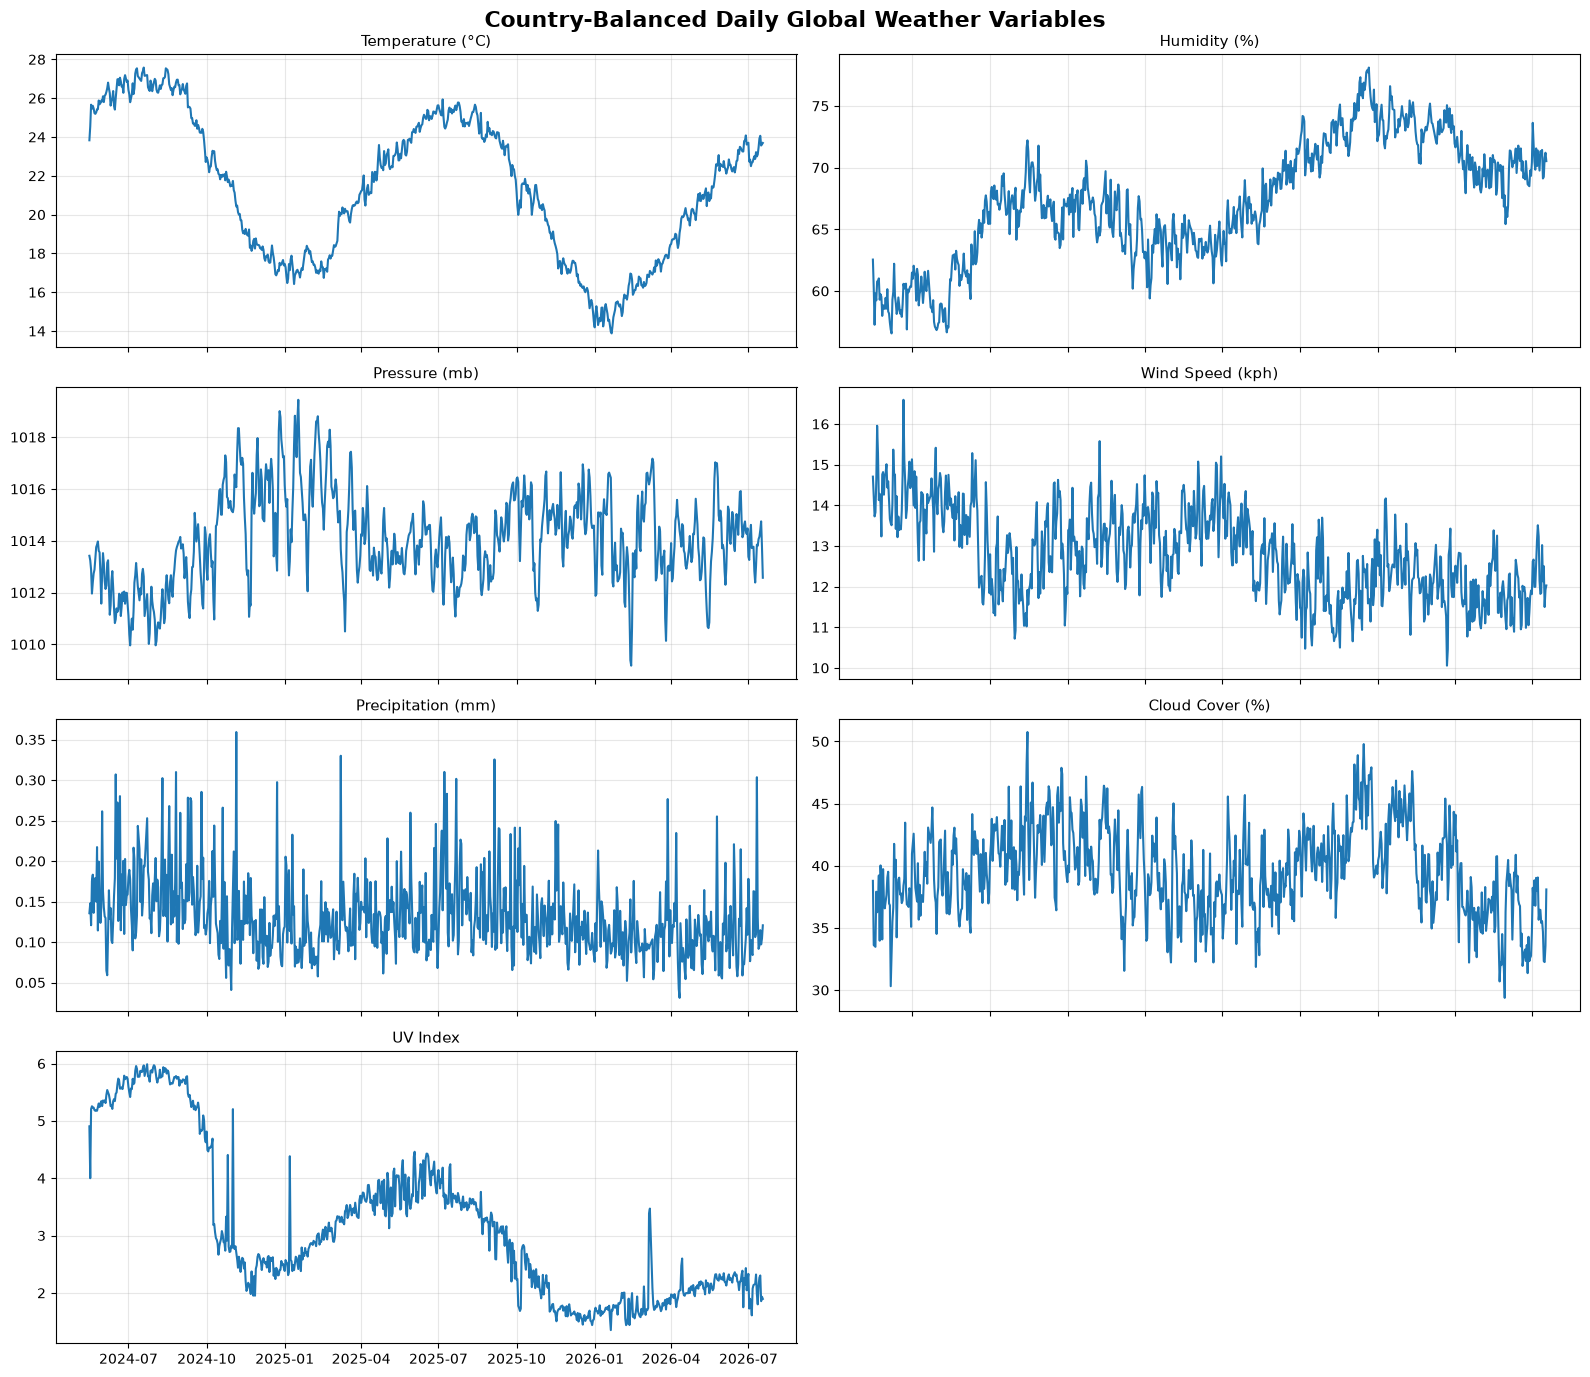

In [220]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16, 14),
    sharex=True
)

axes = axes.flatten()

weather_variables = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "uv_index"
]

titles = [
    "Temperature (°C)",
    "Humidity (%)",
    "Pressure (mb)",
    "Wind Speed (kph)",
    "Precipitation (mm)",
    "Cloud Cover (%)",
    "UV Index"
]

for ax, variable, title in zip(axes, weather_variables, titles):

    ax.plot(
        daily_weather.index,
        daily_weather[variable],
        linewidth=1.5
    )

    ax.set_title(title, fontsize=11)
    ax.grid(alpha=0.3)

# Hide the unused subplot
axes[-1].axis("off")

plt.suptitle(
    "Country-Balanced Daily Global Weather Variables",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 30 Day Rolling Average

Daily values can fluctuate considerably. The rolling average smooths short-term noise and makes broader patterns easier to see.

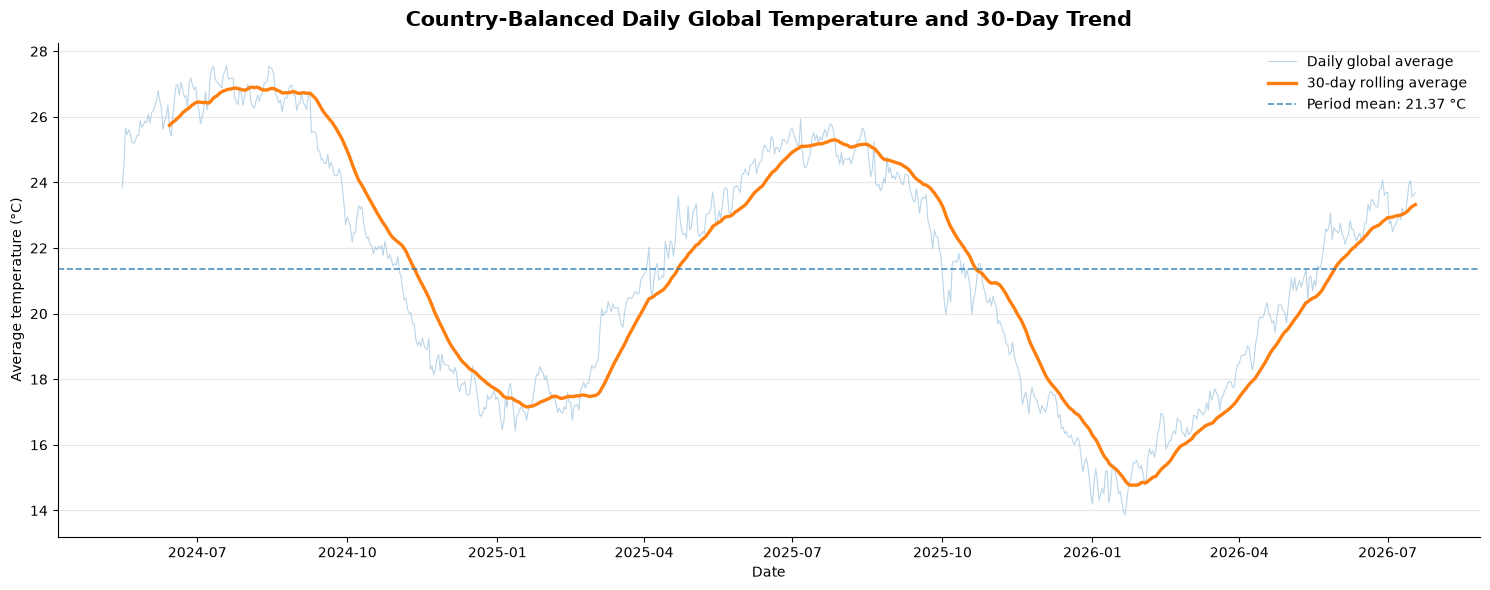

In [223]:
temperature_series = daily_weather["temperature_celsius"]

rolling_30_day = (
    temperature_series
    .rolling(window=30, min_periods=30)
    .mean()
)

overall_mean = temperature_series.mean()

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    temperature_series.index,
    temperature_series,
    alpha=0.3,
    linewidth=0.8,
    label="Daily global average"
)

ax.plot(
    rolling_30_day.index,
    rolling_30_day,
    linewidth=2.4,
    label="30-day rolling average"
)

ax.axhline(
    overall_mean,
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
    label=f"Period mean: {overall_mean:.2f} °C"
)

ax.set_title(
    "Country-Balanced Daily Global Temperature and 30-Day Trend",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Date")
ax.set_ylabel("Average temperature (°C)")

ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

This helps identify seasonal movement more clearly.

### Calculate Autocorrelation

In [224]:
temperature_series = daily_weather["temperature_celsius"]

for lag in [1, 7, 30]:
    autocorrelation = temperature_series.autocorr(lag=lag)

    print(
        f"Lag {lag} autocorrelation:",
        round(autocorrelation, 3)
    )

Lag 1 autocorrelation: 0.996
Lag 7 autocorrelation: 0.979
Lag 30 autocorrelation: 0.875


Interpretation:

- lag=1: relationship with the previous day;
- lag=7: relationship with seven days earlier;
- lag=30: relationship with about one month earlier.

Higher positive values indicate that past temperatures contain useful information for forecasting later temperatures.

### Create the train-test split

In [225]:
TEST_DAYS = 60

train = daily_weather.iloc[:-TEST_DAYS].copy()
test = daily_weather.iloc[-TEST_DAYS:].copy()

print("Training period:")
print(train.index.min(), "to", train.index.max())
print("Training observations:", len(train))

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())
print("Testing observations:", len(test))

Training period:
2024-05-16 00:00:00 to 2026-05-19 00:00:00
Training observations: 734

Testing period:
2026-05-20 00:00:00 to 2026-07-18 00:00:00
Testing observations: 60


Training period:
2024-05-16 00:00:00 to 2026-05-19 00:00:00
Training observations: 734

Testing period:
2026-05-20 00:00:00 to 2026-07-18 00:00:00
Testing observations: 60


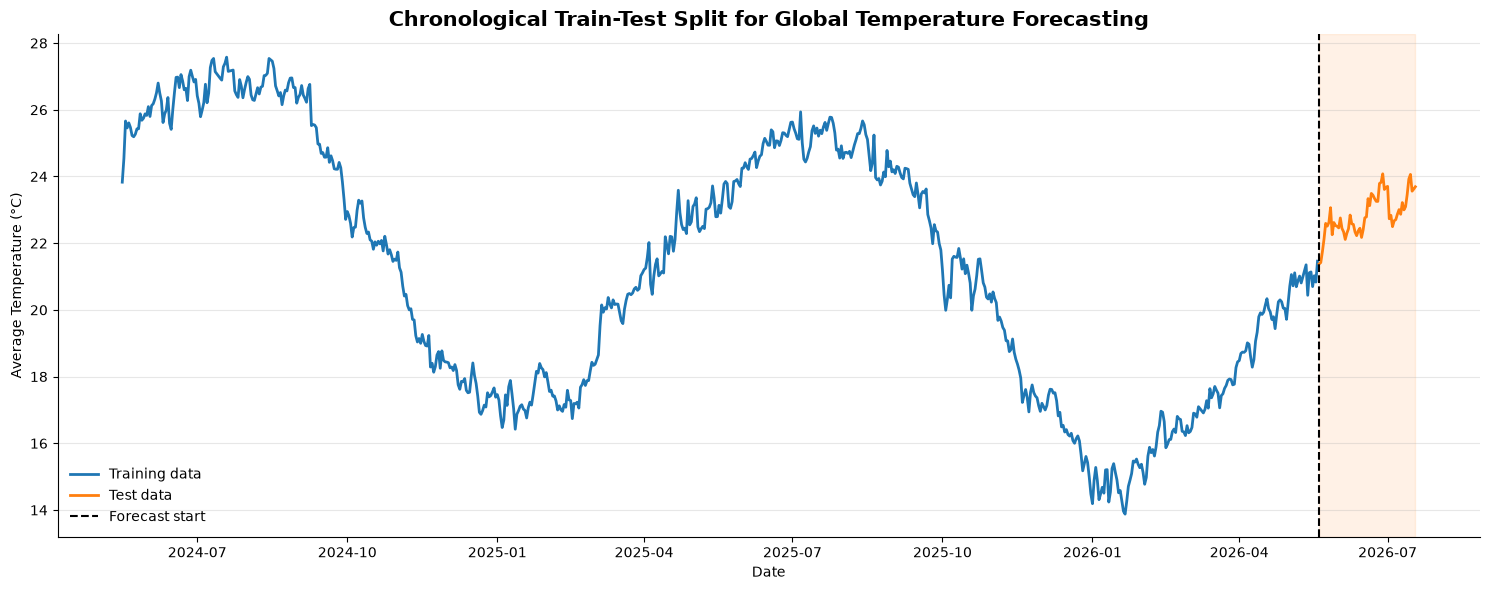

In [227]:
TEST_DAYS = 60

train = daily_weather.iloc[:-TEST_DAYS].copy()
test = daily_weather.iloc[-TEST_DAYS:].copy()

print("Training period:")
print(train.index.min(), "to", train.index.max())
print("Training observations:", len(train))

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())
print("Testing observations:", len(test))

fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    train.index,
    train["temperature_celsius"],
    linewidth=2,
    label="Training data"
)

ax.plot(
    test.index,
    test["temperature_celsius"],
    linewidth=2,
    color="tab:orange",
    label="Test data"
)

ax.axvline(
    test.index.min(),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Forecast start"
)

ax.axvspan(
    test.index.min(),
    test.index.max(),
    color="tab:orange",
    alpha=0.10
)

ax.set_title(
    "Chronological Train-Test Split for Global Temperature Forecasting",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature (°C)")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Forecasting 

##### Naive Forecast

The naive model is the simplest possible forecasting model.

It assumes: Tomorrow will be the same as today

Naive model is used to test more complicated models

### Evaluation Function

In [228]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

def evaluate_forecast(actual, predicted):

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100

    return mae, rmse, mape

### Naive Forecast model

In [232]:
target = "temperature_celsius"

last_temperature = train[target].iloc[-1]

naive_predictions = pd.Series(
    last_temperature,
    index=test.index,
    name="Naive Forecast"
)

In [233]:
naive_mae, naive_rmse, naive_mape = evaluate_forecast(
    test[target],
    naive_predictions
)

print(f"MAE  : {naive_mae:.3f}")
print(f"RMSE : {naive_rmse:.3f}")
print(f"MAPE : {naive_mape:.2f}%")

MAE  : 1.400
RMSE : 1.525
MAPE : 6.06%


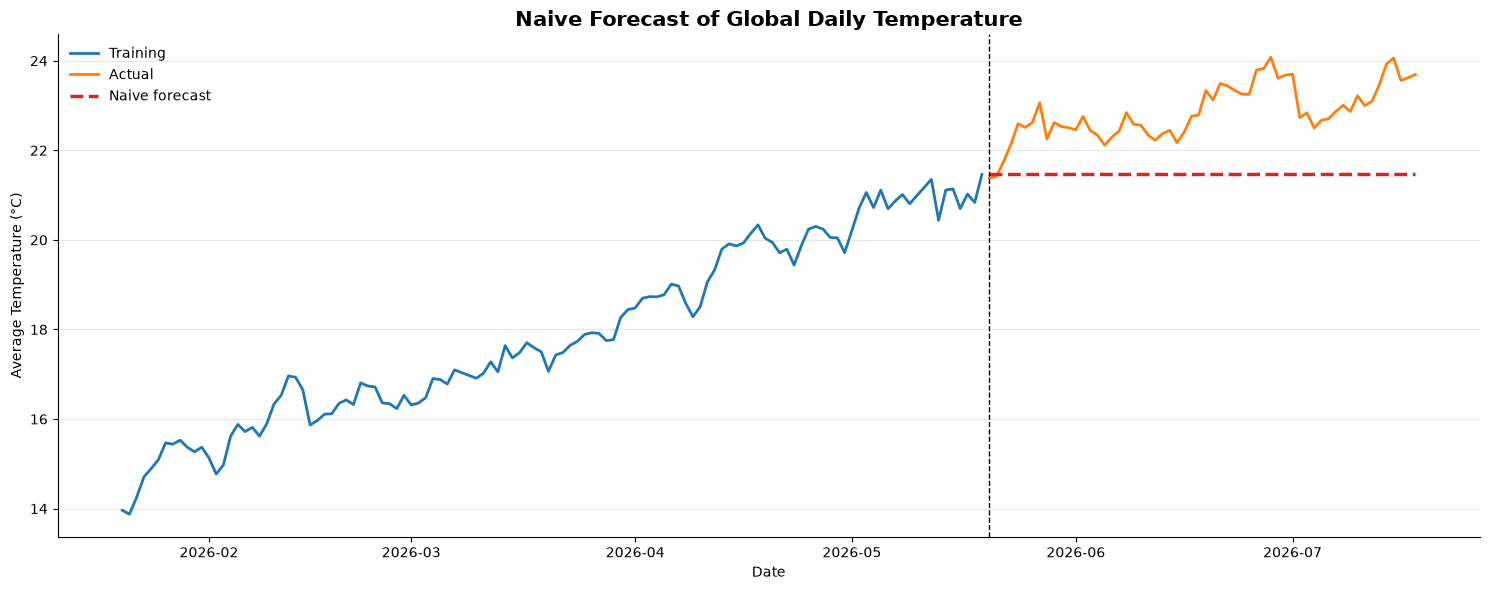

In [234]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    train[target].iloc[-120:],
    linewidth=2,
    label="Training"
)

ax.plot(
    test[target],
    linewidth=2,
    label="Actual"
)

ax.plot(
    naive_predictions,
    "--",
    linewidth=2.5,
    color="tab:red",
    label="Naive forecast"
)

ax.axvline(
    test.index.min(),
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Naive Forecast of Global Daily Temperature",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature (°C)")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

The Naive Forecast was used as the baseline forecasting model. This approach predicts that all future observations will be equal to the final observation in the training set. As shown in Figure X, the model failed to capture the upward trend in the test period, producing a constant forecast that systematically underestimated the observed temperatures. The model achieved an MAE of 1.400°C, RMSE of 1.525°C and MAPE of 6.06%, providing a benchmark for evaluating more advanced forecasting models.

Saving results to compare later

In [235]:
results = []

results.append({
    "Model":"Naive",
    "MAE":naive_mae,
    "RMSE":naive_rmse,
    "MAPE":naive_mape
})

The Naive Forecast model was implemented as the baseline forecasting approach. This method assumes that the future value will be equal to the most recently observed value in the training dataset. Although simplistic, it provides an important benchmark against which more sophisticated forecasting models can be evaluated. Any advanced forecasting model should demonstrate improved predictive accuracy relative to this baseline.

### Seasonal Naive Forecast
Weather often exhibits a short-term weekly cycle due to persistent atmospheric conditions. While weather is not strictly weekly, using a 7-day seasonal lag is a common and simple baseline to test whether recent weekly patterns improve forecasts.

In [239]:
SEASON_LENGTH = 7

target = "temperature_celsius"

temperature_series = daily_weather[target]

seasonal_naive_predictions = (
    temperature_series
    .shift(SEASON_LENGTH)
    .loc[test.index]
    .rename("Seasonal Naive Forecast")
)

In [240]:
seasonal_mae, seasonal_rmse, seasonal_mape = evaluate_forecast(
    test[target],
    seasonal_naive_predictions
)

print(f"MAE  : {seasonal_mae:.3f}")
print(f"RMSE : {seasonal_rmse:.3f}")
print(f"MAPE : {seasonal_mape:.2f}%")

MAE  : 0.619
RMSE : 0.761
MAPE : 2.70%


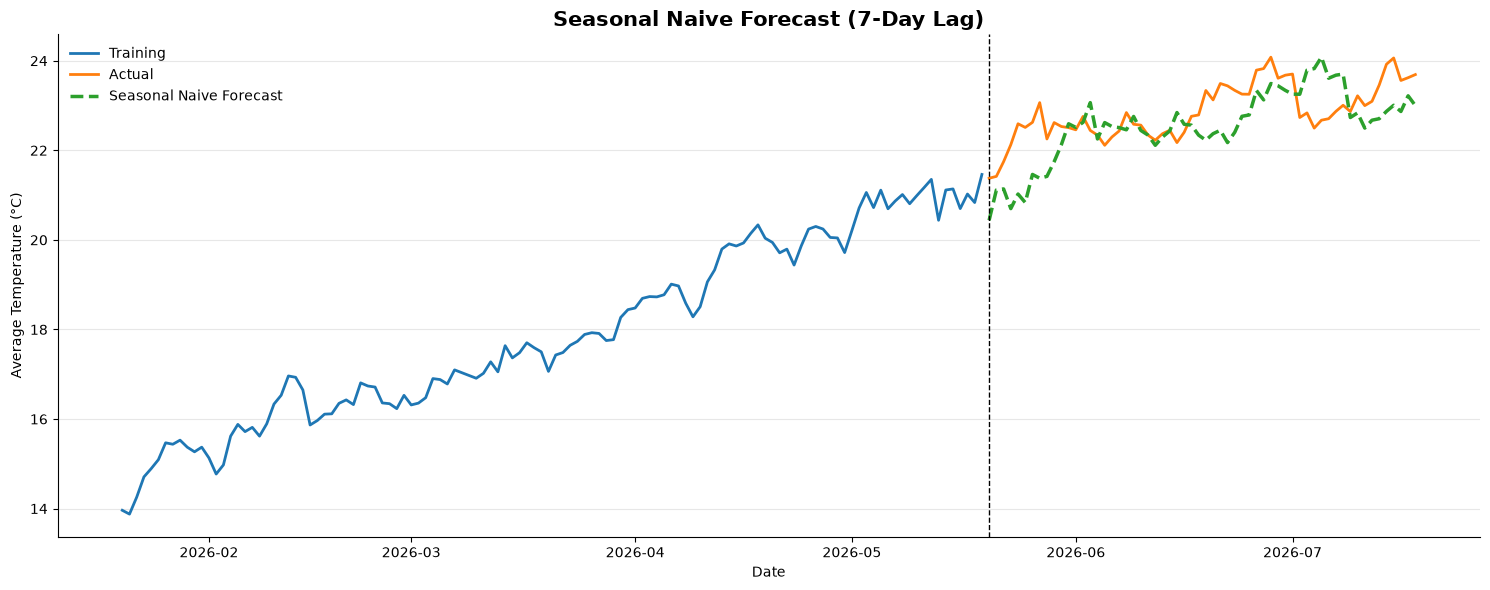

In [241]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    train[target].iloc[-120:],
    linewidth=2,
    label="Training"
)

ax.plot(
    test[target],
    linewidth=2,
    label="Actual"
)

ax.plot(
    seasonal_naive_predictions,
    "--",
    linewidth=2.5,
    color="tab:green",
    label="Seasonal Naive Forecast"
)

ax.axvline(
    test.index.min(),
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Seasonal Naive Forecast (7-Day Lag)",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature (°C)")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [242]:
results.append({
    "Model": "Seasonal Naive",
    "MAE": seasonal_mae,
    "RMSE": seasonal_rmse,
    "MAPE": seasonal_mape
})

pd.DataFrame(results)

,Model,MAE,RMSE,MAPE
0,Naive,1.400245,1.524650,6.059669
1,Seasonal Naive,0.618962,0.761155,2.702814


In [243]:
rmse_improvement = (
    (naive_rmse - seasonal_rmse) / naive_rmse
) * 100

print(f"RMSE improvement: {rmse_improvement:.1f}%")

RMSE improvement: 50.1%


## HOLT Winters


In [244]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [249]:
target = "temperature_celsius"

train_temperature = train[target]
test_temperature = test[target]

holt_model = ExponentialSmoothing(
    train_temperature,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
)

holt_fit = holt_model.fit(
    optimized=True
)

holt_predictions = holt_fit.forecast(
    steps=len(test_temperature)
)

holt_predictions = pd.Series(
    holt_predictions.to_numpy(),
    index=test_temperature.index,
    name="Holt Forecast"
)

In [251]:
holt_mae, holt_rmse, holt_mape = evaluate_forecast(
    test_temperature,
    holt_predictions
)

print(f"MAE  : {holt_mae:.3f}")
print(f"RMSE : {holt_rmse:.3f}")
print(f"MAPE : {holt_mape:.2f}%")

MAE  : 0.472
RMSE : 0.571
MAPE : 2.06%


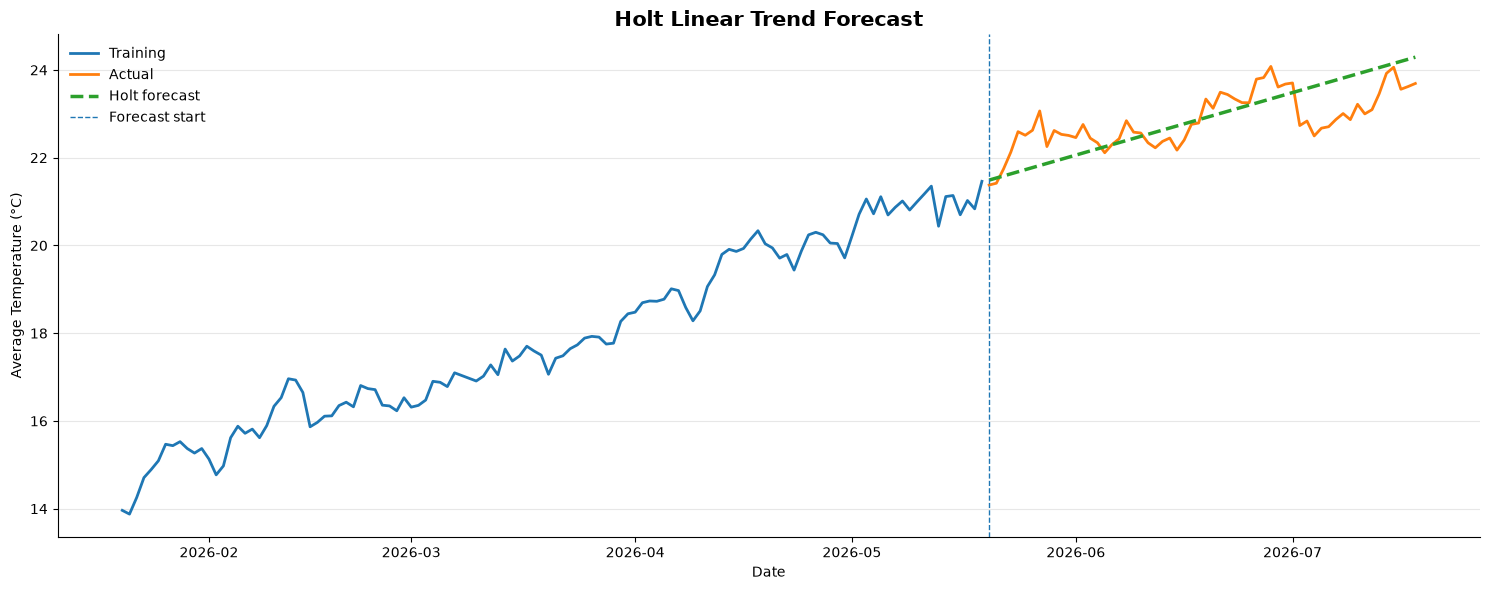

In [252]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    train_temperature.iloc[-120:],
    linewidth=2,
    label="Training"
)

ax.plot(
    test_temperature,
    linewidth=2,
    label="Actual"
)

ax.plot(
    holt_predictions,
    linestyle="--",
    linewidth=2.5,
    label="Holt forecast"
)

ax.axvline(
    test_temperature.index.min(),
    linestyle="--",
    linewidth=1,
    label="Forecast start"
)

ax.set_title(
    "Holt Linear Trend Forecast",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature (°C)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [253]:
results.append({
    "Model":"Holt Linear",
    "MAE":holt_mae,
    "RMSE":holt_rmse,
    "MAPE":holt_mape
})

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
)

display(results_df.round(3))

,Model,MAE,RMSE,MAPE
2,Holt Linear,0.472,0.571,2.060
1,Seasonal Naive,0.619,0.761,2.703
0,Naive,1.400,1.525,6.060


Holt's Linear Trend model extends simple exponential smoothing by incorporating both the current level and the underlying trend of the time series. Unlike the Naive and Seasonal Naive models, Holt's method updates both components as new observations are incorporated, enabling forecasts to continue the observed upward trend. The model achieved the lowest forecasting errors among the baseline methods (MAE = 0.472°C, RMSE = 0.571°C, MAPE = 2.06%), demonstrating that explicitly modelling the trend substantially improves predictive accuracy.

## SARIMA

In [254]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

target = "temperature_celsius"

train_temperature = train[target]
test_temperature = test[target]

sarima_model = SARIMAX(
    train_temperature,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(
    disp=False
)

sarima_predictions = sarima_fit.forecast(
    steps=len(test_temperature)
)

sarima_predictions = pd.Series(
    sarima_predictions.to_numpy(),
    index=test_temperature.index,
    name="SARIMA Forecast"
)

In [255]:
sarima_mae, sarima_rmse, sarima_mape = evaluate_forecast(
    test_temperature,
    sarima_predictions
)

print(f"MAE  : {sarima_mae:.3f}")
print(f"RMSE : {sarima_rmse:.3f}")
print(f"MAPE : {sarima_mape:.2f}%")

MAE  : 1.490
RMSE : 1.611
MAPE : 6.45%


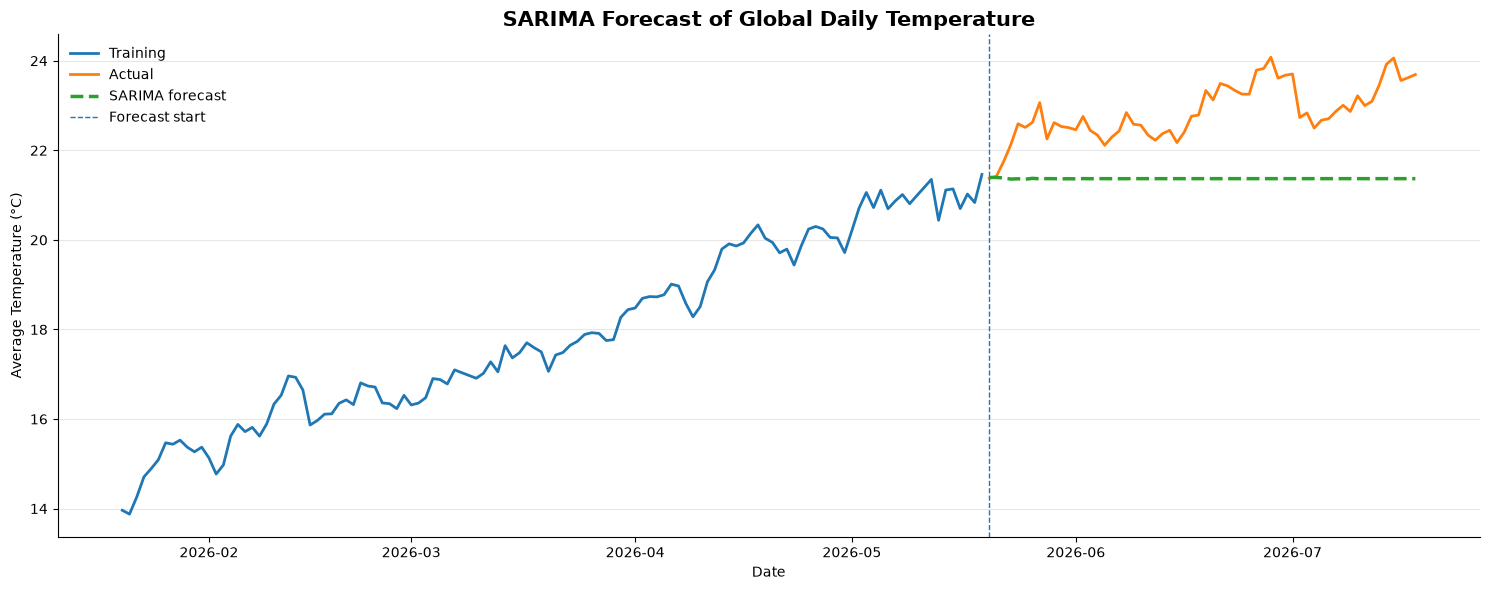

In [256]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    train_temperature.iloc[-120:],
    linewidth=2,
    label="Training"
)

ax.plot(
    test_temperature,
    linewidth=2,
    label="Actual"
)

ax.plot(
    sarima_predictions,
    linestyle="--",
    linewidth=2.5,
    label="SARIMA forecast"
)

ax.axvline(
    test_temperature.index.min(),
    linestyle="--",
    linewidth=1,
    label="Forecast start"
)

ax.set_title(
    "SARIMA Forecast of Global Daily Temperature",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature (°C)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Machine Learning Models


## Random Forest

In [260]:
ml_df = daily_weather.copy()

display(ml_df.head())

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,uv_index
date,,,,,,,
2024-05-16,23.829609,62.543762,1013.418529,14.704562,0.135642,38.786313,4.904097
2024-05-17,24.539980,60.213294,1013.242063,14.202778,0.147857,33.610119,4.000000
2024-05-18,25.663128,57.260708,1012.878957,13.726536,0.120782,33.552142,5.206704
2024-05-19,25.456180,59.797753,1011.959738,13.825936,0.175318,33.477528,5.254682
2024-05-20,25.606425,59.239292,1012.387337,14.611359,0.183194,37.911546,5.231844


In [261]:
for lag in [1, 2, 3, 7, 14, 30]:
    ml_df[f"temp_lag_{lag}"] = (
        ml_df["temperature_celsius"]
        .shift(lag)
    )

In [262]:
past_temperature = ml_df["temperature_celsius"].shift(1)

ml_df["temp_roll_mean_7"] = (
    past_temperature
    .rolling(7)
    .mean()
)

ml_df["temp_roll_mean_14"] = (
    past_temperature
    .rolling(14)
    .mean()
)

ml_df["temp_roll_std_7"] = (
    past_temperature
    .rolling(7)
    .std()
)

ml_df["temp_roll_min_7"] = (
    past_temperature
    .rolling(7)
    .min()
)

ml_df["temp_roll_max_7"] = (
    past_temperature
    .rolling(7)
    .max()
)

In [263]:
weather_variables = [
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "cloud",
    "uv_index"
]

for variable in weather_variables:

    ml_df[f"{variable}_lag_1"] = (
        ml_df[variable]
        .shift(1)
    )

In [279]:
ml_df["doy_sin"] = np.sin(
    2 * np.pi * ml_df.index.dayofyear / 365.25
)

ml_df["doy_cos"] = np.cos(
    2 * np.pi * ml_df.index.dayofyear / 365.25
)

In [280]:
ml_df = ml_df.dropna()

print(ml_df.shape)

(764, 29)


In [281]:
TARGET = "temperature_celsius"

X = ml_df.drop(columns=TARGET)

y = ml_df[TARGET]

In [282]:
TEST_DAYS = 60

X_train = X.iloc[:-TEST_DAYS]
X_test = X.iloc[-TEST_DAYS:]

y_train = y.iloc[:-TEST_DAYS]
y_test = y.iloc[-TEST_DAYS:]

In [283]:
ml_df

,temperature_celsius,humidity,pressure_mb,wind_kph,precip_mm,cloud,uv_index,temp_lag_1,temp_lag_2,temp_lag_3,...,pressure_mb_lag_1,wind_kph_lag_1,precip_mm_lag_1,cloud_lag_1,uv_index_lag_1,day_of_year,month,day_of_week,doy_sin,doy_cos
date,,,,,,,,,,,,,,,,,,,,,
2024-06-15,25.412271,59.474359,1010.821429,13.721520,0.178764,38.896520,5.344322,25.594505,26.366850,25.997070,...,1011.398352,13.215476,0.156786,37.915751,5.379121,167,6,5,0.265563,-0.964094
2024-06-16,26.010531,58.802198,1010.965201,13.390293,0.306996,39.044872,5.472527,25.412271,25.594505,26.366850,...,1010.821429,13.721520,0.178764,38.896520,5.344322,168,6,6,0.248940,-0.968519
2024-06-17,26.512524,58.166667,1011.387947,13.472222,0.203145,37.686441,5.494350,26.010531,25.412271,25.594505,...,1010.965201,13.390293,0.306996,39.044872,5.472527,169,6,0,0.232243,-0.972658
2024-06-18,26.971375,58.442561,1011.254237,13.408569,0.272345,37.790019,5.636535,26.512524,26.010531,25.412271,...,1011.387947,13.472222,0.203145,37.686441,5.494350,170,6,1,0.215477,-0.976509
2024-06-19,26.979284,57.902072,1011.339925,13.863936,0.126073,36.993409,5.737288,26.971375,26.512524,26.010531,...,1011.254237,13.408569,0.272345,37.790019,5.636535,171,6,2,0.198648,-0.980071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-14,23.921823,69.116943,1014.155617,12.130295,0.095663,34.686924,2.267403,23.458652,23.094000,22.998087,...,1014.062842,13.020492,0.091648,35.544627,2.126503,195,7,1,-0.211276,-0.977426
2026-07-15,24.061749,69.244080,1014.407104,12.502732,0.114672,32.319672,2.304372,23.921823,23.458652,23.094000,...,1014.155617,12.130295,0.095663,34.686924,2.267403,196,7,2,-0.228058,-0.973648
2026-07-16,23.559444,70.775000,1014.747222,11.498056,0.097139,32.252778,1.856111,24.061749,23.921823,23.458652,...,1014.407104,12.502732,0.114672,32.319672,2.304372,197,7,3,-0.244772,-0.969581


In [284]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_predictions = pd.Series(
    rf.predict(X_test),
    index=y_test.index
)

In [285]:
rf_mae, rf_rmse, rf_mape = evaluate_forecast(
    y_test,
    rf_predictions
)

print(f"MAE  : {rf_mae:.3f}")
print(f"RMSE : {rf_rmse:.3f}")
print(f"MAPE : {rf_mape:.2f}%")

MAE  : 0.319
RMSE : 0.404
MAPE : 1.40%


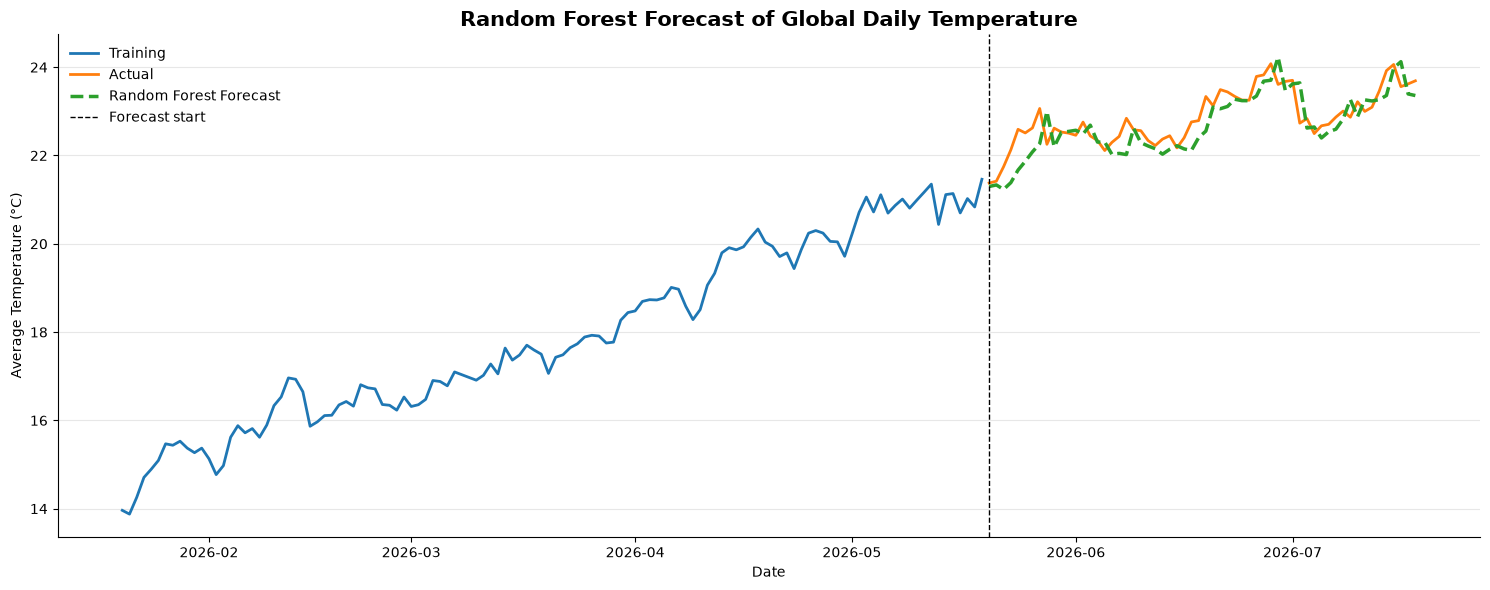

In [286]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(
    y_train.iloc[-120:],
    linewidth=2,
    label="Training"
)

ax.plot(
    y_test,
    linewidth=2,
    label="Actual"
)

ax.plot(
    rf_predictions,
    linestyle="--",
    linewidth=2.5,
    label="Random Forest Forecast"
)

ax.axvline(
    y_test.index.min(),
    color="black",
    linestyle="--",
    linewidth=1,
    label="Forecast start"
)

ax.set_title(
    "Random Forest Forecast of Global Daily Temperature",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Date")
ax.set_ylabel("Average Temperature (°C)")

ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [287]:
results.append({
    "Model":"Random Forest",
    "MAE":rf_mae,
    "RMSE":rf_rmse,
    "MAPE":rf_mape
})

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df.round(3))

,Model,MAE,RMSE,MAPE
0,Random Forest,0.319,0.404,1.397
1,Holt Linear,0.472,0.571,2.060
2,Seasonal Naive,0.619,0.761,2.703
3,Naive,1.400,1.525,6.060


In [288]:
feature_importance = (
    pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance.head(15))

,Feature,Importance
6,temp_lag_1,0.892282
15,temp_roll_min_7,0.045463
7,temp_lag_2,0.017664
5,uv_index,0.014702
8,temp_lag_3,0.012566
12,temp_roll_mean_7,0.008131
16,temp_roll_max_7,0.004159
0,humidity,0.000502
23,day_of_year,0.000411
22,uv_index_lag_1,0.000389


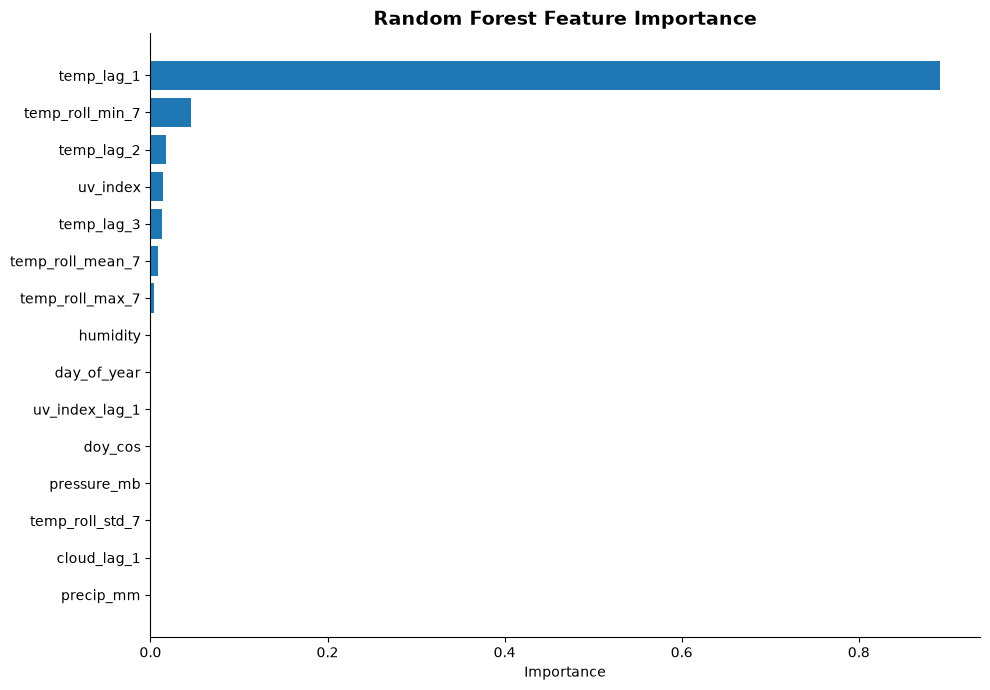

In [290]:
top_features = feature_importance.head(15)

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    top_features["Feature"],
    top_features["Importance"]
)

ax.invert_yaxis()

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Importance")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Feature importance analysis indicated that the Random Forest model relied predominantly on recent observations. The previous day's temperature (lag_1) accounted for approximately 83% of the total feature importance, followed by the seven-day rolling mean (13.8%). Longer lag variables and calendar-based features contributed comparatively little, indicating that short-term temporal dependencies were the strongest predictors of future temperature.

### XGBoost

In [291]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)




In [292]:
xgb_model.fit(
    X_train,
    y_train
)
xgb_predictions = pd.Series(
    xgb_model.predict(X_test),
    index=y_test.index
)

xgb_mae, xgb_rmse, xgb_mape = evaluate_forecast(
    y_test,
    xgb_predictions
)

print(f"MAE  : {xgb_mae:.3f}")
print(f"RMSE : {xgb_rmse:.3f}")
print(f"MAPE : {xgb_mape:.2f}%")


MAE  : 0.373
RMSE : 0.445
MAPE : 1.63%


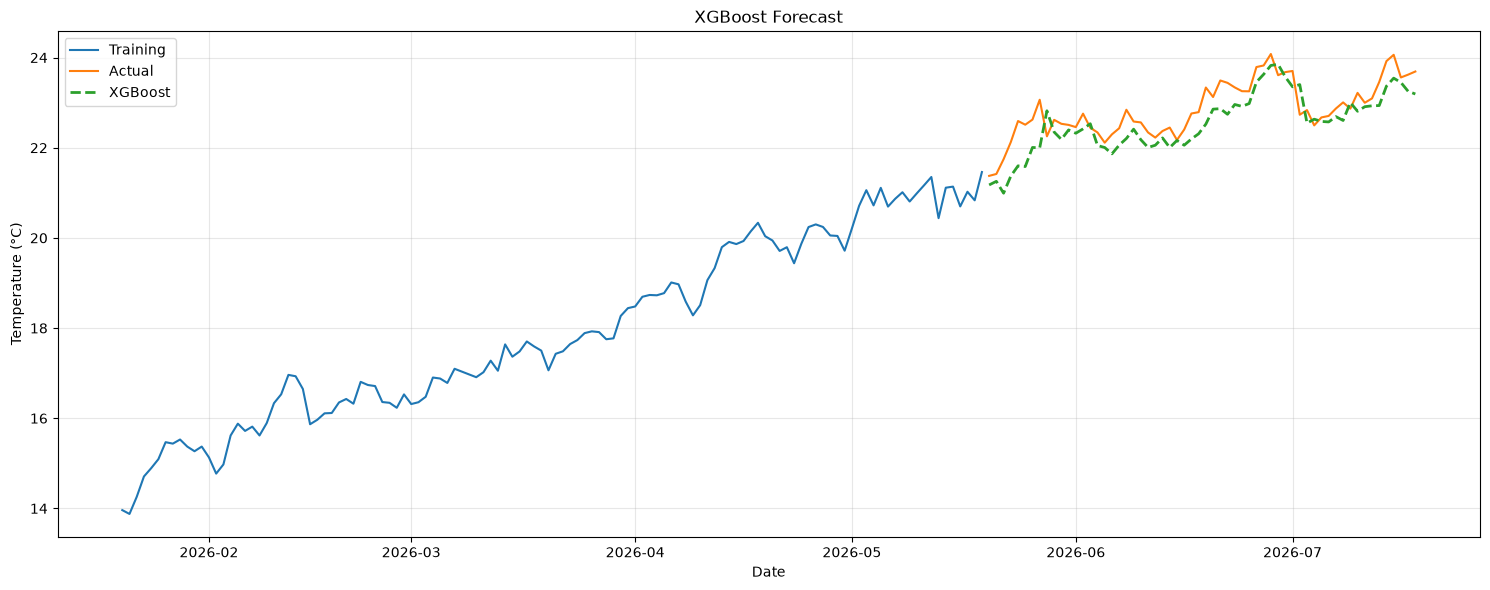

In [293]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.iloc[-120:],
    label="Training"
)

plt.plot(
    y_test,
    label="Actual"
)

plt.plot(
    xgb_predictions,
    "--",
    linewidth=2,
    label="XGBoost"
)

plt.title("XGBoost Forecast")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [294]:
results.append({
    "Model": "XGBoost",
    "MAE": xgb_mae,
    "RMSE": xgb_rmse,
    "MAPE": xgb_mape
})

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df.round(3))

,Model,MAE,RMSE,MAPE
0,Random Forest,0.319,0.404,1.397
1,XGBoost,0.373,0.445,1.630
2,Holt Linear,0.472,0.571,2.060
3,Seasonal Naive,0.619,0.761,2.703
4,Naive,1.400,1.525,6.060


In [295]:
xgb_importance = (
    pd.Series(
        xgb_model.feature_importances_,
        index=X_train.columns
    )
    .sort_values(ascending=False)
)

display(xgb_importance)

temp_roll_min_7      0.372397
temp_lag_1           0.360286
temp_lag_2           0.143475
temp_roll_max_7      0.039484
temp_lag_3           0.025930
temp_roll_mean_7     0.024071
temp_roll_mean_14    0.013300
uv_index             0.008184
temp_lag_7           0.004056
doy_cos              0.001129
uv_index_lag_1       0.001072
humidity             0.000810
temp_lag_14          0.000723
day_of_year          0.000711
doy_sin              0.000475
cloud_lag_1          0.000422
temp_lag_30          0.000389
cloud                0.000380
pressure_mb          0.000331
day_of_week          0.000317
temp_roll_std_7      0.000313
pressure_mb_lag_1    0.000312
humidity_lag_1       0.000306
wind_kph_lag_1       0.000262
wind_kph             0.000232
month                0.000229
precip_mm_lag_1      0.000212
precip_mm            0.000194
dtype: float32

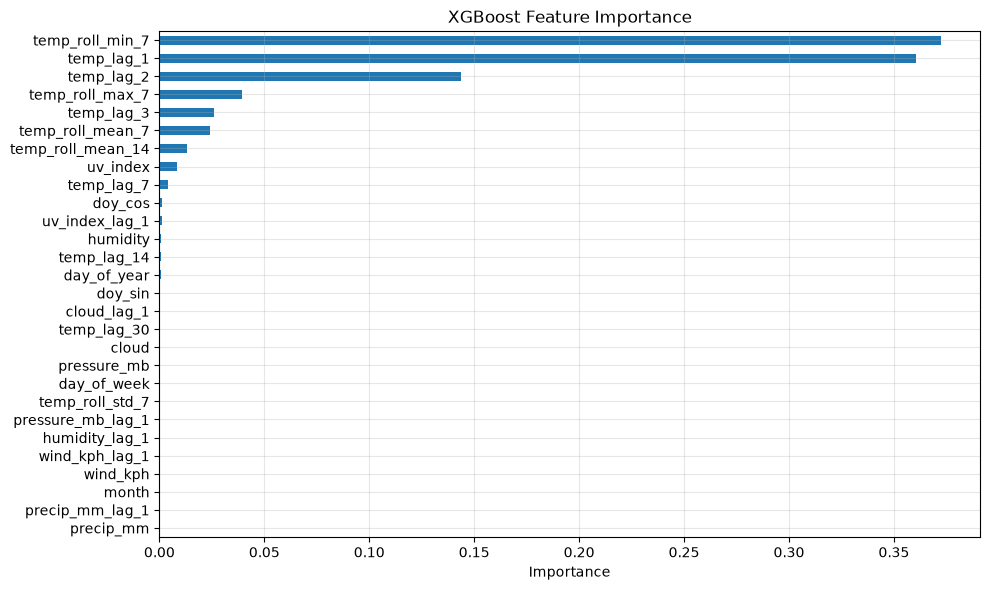

In [296]:
plt.figure(figsize=(10,6))

xgb_importance.sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Ensemble Models (Random Forest + XGBoost)

In [297]:
ensemble_predictions = (
    rf_predictions +
    xgb_predictions
) / 2

ensemble_mae, ensemble_rmse, ensemble_mape = evaluate_forecast(
    y_test,
    ensemble_predictions
)

print(f"MAE  : {ensemble_mae:.3f}")
print(f"RMSE : {ensemble_rmse:.3f}")
print(f"MAPE : {ensemble_mape:.2f}%")

MAE  : 0.335
RMSE : 0.410
MAPE : 1.47%


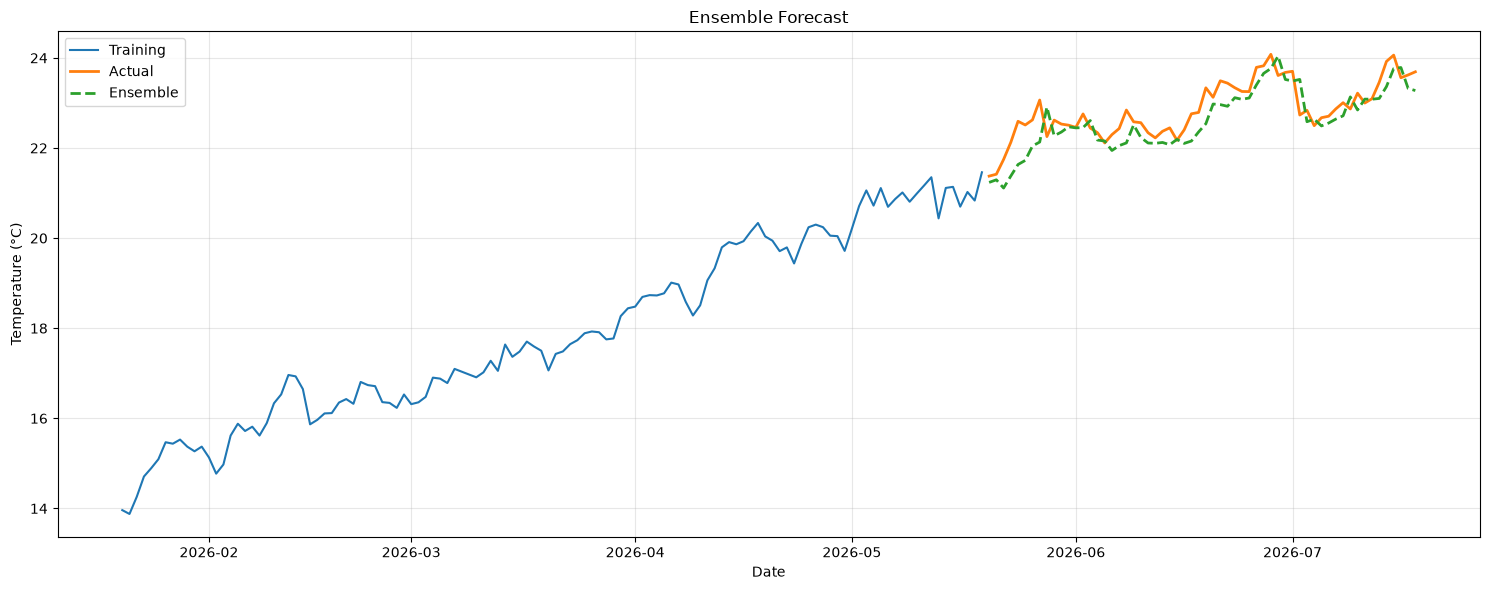

In [298]:
plt.figure(figsize=(15,6))

plt.plot(
    y_train.iloc[-120:],
    label="Training"
)

plt.plot(
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    ensemble_predictions,
    "--",
    linewidth=2,
    label="Ensemble"
)

plt.title("Ensemble Forecast")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [300]:
results.append({
    "Model":"Ensemble",
    "MAE":ensemble_mae,
    "RMSE":ensemble_rmse,
    "MAPE":ensemble_mape
})

results_df = (
    pd.DataFrame(results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(results_df.round(3))

,Model,MAE,RMSE,MAPE
0,Random Forest,0.319,0.404,1.397
1,Ensemble,0.335,0.410,1.466
2,Ensemble,0.335,0.410,1.466
3,XGBoost,0.373,0.445,1.630
4,Holt Linear,0.472,0.571,2.060
5,Seasonal Naive,0.619,0.761,2.703
6,Naive,1.400,1.525,6.060


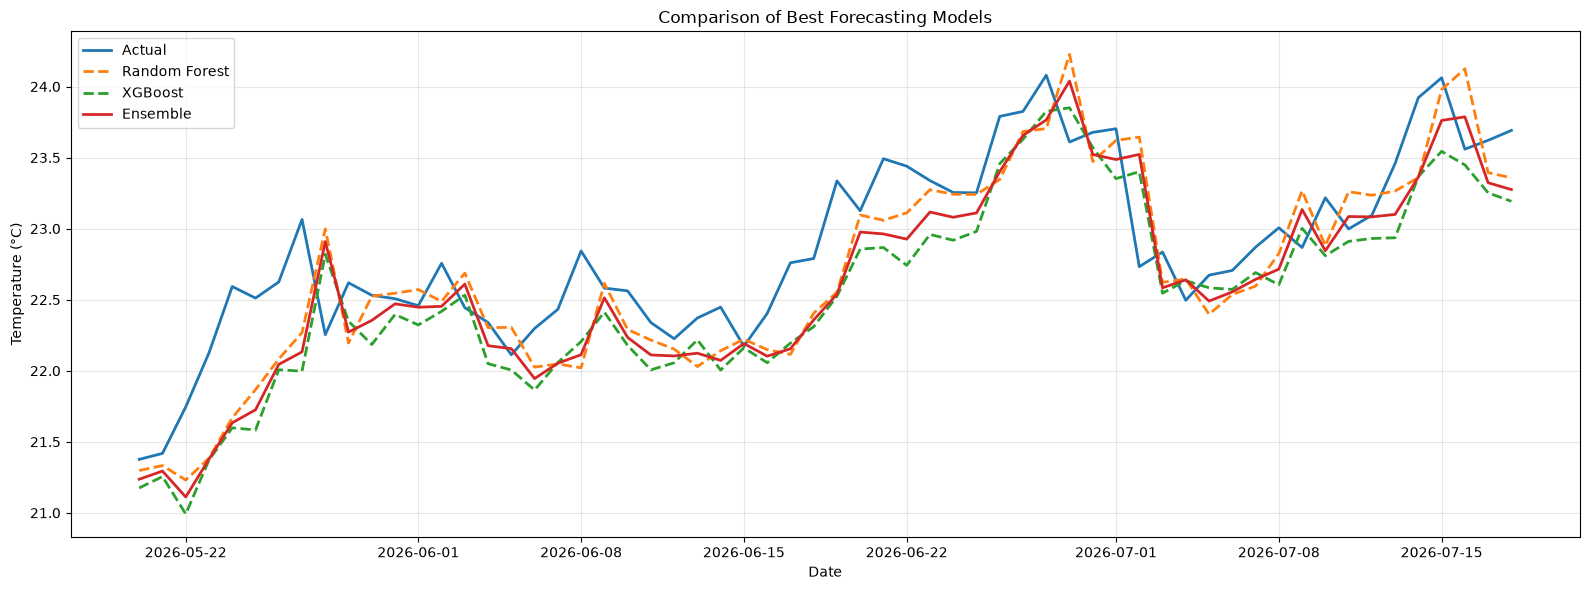

In [301]:
plt.figure(figsize=(16,6))

plt.plot(
    y_test,
    linewidth=2,
    label="Actual"
)

plt.plot(
    rf_predictions,
    "--",
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    xgb_predictions,
    "--",
    linewidth=2,
    label="XGBoost"
)

plt.plot(
    ensemble_predictions,
    linewidth=2,
    label="Ensemble"
)

plt.title("Comparison of Best Forecasting Models")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [303]:
comparison = pd.DataFrame({
    "Model": [
        "Naive",
        "Seasonal Naive",
        "Holt",
        "SARIMA",
        "Random Forest",
        "XGBoost",
        "RF-XGBoost Ensemble"
    ],
    "MAE": [
        naive_mae,
        seasonal_mae,
        holt_mae,
        sarima_mae,
        rf_mae,
        xgb_mae,
        ensemble_mae
    ],
    "RMSE": [
        naive_rmse,
        seasonal_rmse,
        holt_rmse,
        sarima_rmse,
        rf_rmse,
        xgb_rmse,
        ensemble_rmse
    ],
    "MAPE": [
        naive_mape,
        seasonal_mape,
        holt_mape,
        sarima_mape,
        rf_mape,
        xgb_mape,
        ensemble_mape
    ]
}).sort_values("RMSE")

display(comparison.round(3))

,Model,MAE,RMSE,MAPE
4,Random Forest,0.319,0.404,1.397
6,RF-XGBoost Ensemble,0.335,0.410,1.466
5,XGBoost,0.373,0.445,1.630
2,Holt,0.472,0.571,2.060
1,Seasonal Naive,0.619,0.761,2.703
0,Naive,1.400,1.525,6.060
3,SARIMA,1.490,1.611,6.451
